# Two-scale proof of the SPI-SPI feature space `f_ij = corr(SPI_i, SPI_j)`

A single feature space, two claims, on the benchmarked90 (297-SPI) run at matched (M,T) grids:

- **Panel A - multi-class (coarse).** 8 structurally distinct generators + 2 CML bridge regimes
  (`defect-turbulence`, `sti-i`) separate cleanly. Establishes credibility.
- **Panel B - intra-CML (fine).** A reduced set of CML regimes - subtle *same-family* dynamics -
  still separate, and the same regime at different (M,T) co-locates (dimension/length invariance
  that conventional feature-based MTS methods cannot provide).

The two **bridge classes** appear in both panels: one cluster among ten in A, a resolved
sub-manifold in B. They are the *same underlying datasets* in both (Panel A reuses the CML runs
by symlink), so the link is exact, not an analogy.

Matrices: `multi_p90_260701_pearson.npz` (10 classes, 900 samples) and
`cml-embedding_pearson.npz` (6 CML regimes, 540 samples).

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from dataclasses import dataclass, field

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from umap import UMAP

mpl.rcParams.update(
    {"text.usetex": False}
)

# Local plot_pca/plot_umap are defined below (Section 2). They intentionally replace
# src.visualization.plot_pca, which hard-codes StandardScaler (correlation PCA) and
# takes no palette -- wrong for the bounded f_ij space + no colour lock.

In [86]:
mpl.rcParams.keys()

KeysView(RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'b

## Class colour lock

The two CML bridge regimes (`defect-turbulence`, `sti-i`) appear in **both** panels. Pin their
colours so the eye tracks them A -> B; other classes fill from a pool in sorted order. Pick ONE
palette below (two commented out). Option 1 (colourblind-safe) is the recommended publication
default; Option 2 is pastel/rainbow; Option 3 is seaborn "deep".

In [87]:
# --- Option 1 (optimal: colourblind-safe; bridges vivid so they pop) --------------
BRIDGE = ["defect-turbulence", "sti-i"]
BRIDGE_HEX = ["#D81B60", "#1E88E5"]                     # crimson, blue
POOL = sns.color_palette("colorblind")                 # 10 muted CB-safe for the rest

# --- Option 2 (pastel / rainbow: husl, evenly spaced hues) ------------------------
# BRIDGE = ["defect-turbulence", "sti-i"]
# BRIDGE_HEX = list(sns.color_palette("husl", 10)[:2])
# POOL = sns.color_palette("husl", 10)[2:]

# --- Option 3 (seaborn "deep") ----------------------------------------------------
# BRIDGE = ["defect-turbulence", "sti-i"]
# BRIDGE_HEX = list(sns.color_palette("deep", 10)[:2])
# POOL = sns.color_palette("deep", 10)[2:]

def class_colors(classes):
    """class -> colour; bridge classes fixed (identical in every panel), others fill POOL in
    sorted order for stability. Use as seaborn palette= with hue_order=list(cc)."""
    bmap = dict(zip(BRIDGE, BRIDGE_HEX))
    pool = iter(POOL)
    ordered = [c for c in BRIDGE if c in set(classes)] + sorted(c for c in set(classes) if c not in BRIDGE)
    return {c: (bmap[c] if c in bmap else next(pool)) for c in ordered}

## 1 - Feature sets

Both matrices share the benchmarked90 SPI set, so `f_ij` columns are comparable. Each is wrapped
in a lightweight `FeatureSet` carrying `X, y, M, T, instance, pairs` plus an order-independent
`(spi_i, spi_j) -> column` index. `.subset(classes=..., M_filter=...)` selects for a panel without
touching the full set used by the discrimination tools below.

In [88]:
@dataclass
class FeatureSet:
    """SPI-SPI feature matrix + metadata. One per data run (multi-class / CML)."""
    name: str
    X: np.ndarray
    y: np.ndarray
    M: np.ndarray
    T: np.ndarray
    instance: np.ndarray
    dataset_paths: np.ndarray
    pairs: np.ndarray
    _pair_index: dict = field(default=None, repr=False)

    def __post_init__(self):
        self._pair_index = {}
        for k, (a, b) in enumerate(self.pairs):
            self._pair_index[(a, b)] = k
            self._pair_index[(b, a)] = k

    @property
    def meta_df(self):
        return pd.DataFrame({"mts_class": self.y, "M": self.M, "T": self.T,
                             "instance": self.instance, "dataset_paths": self.dataset_paths})

    def feature_column(self, spi_i, spi_j):
        """Column index of corr(spi_i, spi_j) (order-independent)."""
        try:
            return self._pair_index[(spi_i, spi_j)]
        except KeyError:
            raise KeyError(f"no feature for ({spi_i}, {spi_j}); check names in fs.pairs.")

    def subset(self, classes=None, M_filter=None):
        mask = np.ones(len(self.y), bool)
        if classes is not None:
            mask &= np.isin(self.y, classes)
        if M_filter is not None:
            mask &= self.M == M_filter
        return FeatureSet(self.name, self.X[mask], self.y[mask], self.M[mask], self.T[mask],
                          self.instance[mask], self.dataset_paths[mask], self.pairs)


def load_featureset(path, name):
    d = np.load(path, allow_pickle=True)
    return FeatureSet(name, d["X"].astype(float), d["y"], d["M"].astype(int),
                      d["T"].astype(int), d["instance"], d["dataset_paths"], d["pairs"])


MULTI = load_featureset("../../features/data-embeddings-multi_p90_260701_pearson.npz", "multi")
CML   = load_featureset("../../features/data-embeddings-cml-embedding_pearson.npz",    "cml")
print(f"MULTI  X={MULTI.X.shape}  classes={sorted(set(MULTI.y))}")
print(f"CML    X={CML.X.shape}  classes={sorted(set(CML.y))}")

MULTI  X=(900, 40184)  classes=[np.str_('cauchy-noise'), np.str_('defect-turbulence'), np.str_('gaussian-noise'), np.str_('kuramoto_omega-fast'), np.str_('kuramoto_omega-slow'), np.str_('sti-i'), np.str_('var-phi-0.2_cpl-0.4'), np.str_('var-phi-0.2_cpl-0.8'), np.str_('var-phi-0.95_cpl-0.4'), np.str_('wave-1d')]
CML    X=(540, 40174)  classes=[np.str_('brownian-defect'), np.str_('chaotic-traveling-wave'), np.str_('defect-turbulence'), np.str_('fdstc'), np.str_('frozen-chaos'), np.str_('sti-i')]


## 2 - Embedding & plotting helpers

`plot_pca(fs)` / `plot_umap(fs)` take a FeatureSet, default to `scaled=False` (covariance PCA,
correct for the bounded f_ij space), colour by the shared lock, size points by M, and return
`(emb, df, ax)` so the combined figure reuses the same embeddings. These deliberately replace
`src.visualization.plot_pca` (which forces StandardScaler and takes no palette).

In [89]:
# --- shared embedding hyperparameters (both panels) ---
N_NEIGHBORS = 25
MIN_DIST = 0.75
METRIC = "euclidean"       # after PCA, euclidean is the standard choice
SCALED = False             # covariance-PCA keeps high-variance f_ij pairs dominant
PCA_PREPROCESS = True      # p >> n: denoise/decorrelate within f_ij space before UMAP
N_PCA = 50


def _scatter(df, xcol, ycol, *, ax=None, colors=None, size_col="M", sizes=(20, 200), kde=True,
             alpha=0.35, edge_alpha=None, legend_title="class"):
    """Colour-locked scatter of a 2D embedding df (+ optional KDE contours), sized by M."""
    if colors is None:
        colors = class_colors(df["mts_class"].unique())
    order = list(colors)
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 6), dpi=150)
    if kde:
        sns.kdeplot(data=df, x=xcol, y=ycol, hue="mts_class", hue_order=order, palette=colors,
                    levels=5, alpha=0.25, linewidths=1, ax=ax, legend=False)
    sns.scatterplot(data=df, x=xcol, y=ycol, hue="mts_class", hue_order=order, palette=colors,
                    size=size_col, sizes=sizes, alpha=alpha, edgecolor="face", ax=ax, legend="full")
    if edge_alpha is not None:                      # faint fill, stronger outline (matplotlib
        coll = ax.collections[-1]                   # alpha is one scalar; bake per-channel here)
        fc = coll.get_facecolors().copy(); ec = fc.copy()
        fc[:, 3] = alpha; ec[:, 3] = edge_alpha
        coll.set_alpha(None)                        # else the scalar alpha overrides per-channel
        coll.set_facecolors(fc); coll.set_edgecolors(ec); coll.set_linewidths(0.7)
    ax.set_box_aspect(1)
    ax.legend(title=legend_title, loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8, frameon=True)
    return ax


def plot_pca(fs, *, scaled=False, ax=None, title=None, alpha=0.35, **kw):
    """PCA-2D of a FeatureSet. scaled=False -> covariance PCA (correct for the bounded
    f_ij space; high-variance pairs stay dominant). Returns (emb, df, ax)."""
    X = StandardScaler().fit_transform(fs.X) if scaled else fs.X
    pca = PCA(n_components=2, random_state=0).fit(X)
    emb = pca.transform(X); v = pca.explained_variance_ratio_
    df = fs.meta_df.assign(pc_x=emb[:, 0], pc_y=emb[:, 1])
    ax = _scatter(df, "pc_x", "pc_y", alpha=alpha, ax=ax, **kw)
    ax.set_title(title or f"PCA [{fs.name}]  var PC1+PC2 = {v[:2].sum():.2f}")
    ax.set_xlabel(f"PC1 ({v[0]:.2f})"); ax.set_ylabel(f"PC2 ({v[1]:.2f})")
    return emb, df, ax


def plot_umap(fs, *, n_neighbors=N_NEIGHBORS, min_dist=MIN_DIST, spread=1.0, n_pca=N_PCA,
              metric=METRIC, scaled=SCALED, pca_preprocess=PCA_PREPROCESS, seed=0,
              ax=None, title=None, alpha=0.35, **kw):
    """UMAP-2D of a FeatureSet: (optional PCA-preprocess) -> UMAP -> colour-locked scatter.
    Every embedding arg below is used directly (no indirection). **kw -> _scatter
    (kde, legend_title, colors, size_col). Returns (emb, df, ax)."""
    Xin = StandardScaler().fit_transform(fs.X) if scaled else fs.X
    n_pca_eff = "off"
    if pca_preprocess:
        n_pca_eff = min(n_pca, *Xin.shape)
        pca = PCA(n_components=n_pca_eff, random_state=seed).fit(Xin)
        Xin = pca.transform(Xin)
        print(f"[{fs.name}] PCA {fs.X.shape[1]} -> {n_pca_eff} PCs | "
              f"cum var = {pca.explained_variance_ratio_.sum():.3f}")
    emb = UMAP(n_neighbors=n_neighbors, min_dist=min_dist, spread=spread, metric=metric,
               random_state=seed).fit_transform(Xin)
    df = fs.meta_df.assign(umap_x=emb[:, 0], umap_y=emb[:, 1])
    tag = f"NN={n_neighbors}, min_dist={min_dist}, spread={spread}, {metric}, pca={n_pca_eff}"
    ax = _scatter(df, "umap_x", "umap_y", alpha=alpha, ax=ax, **kw)
    ax.set_title(title or f"UMAP [{fs.name}] ({tag})")
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
    return emb, df, ax

## 3 - Panel A - multi-class separation (coarse)

All 10 classes (8 distinct generators + the 2 CML bridge regimes).

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

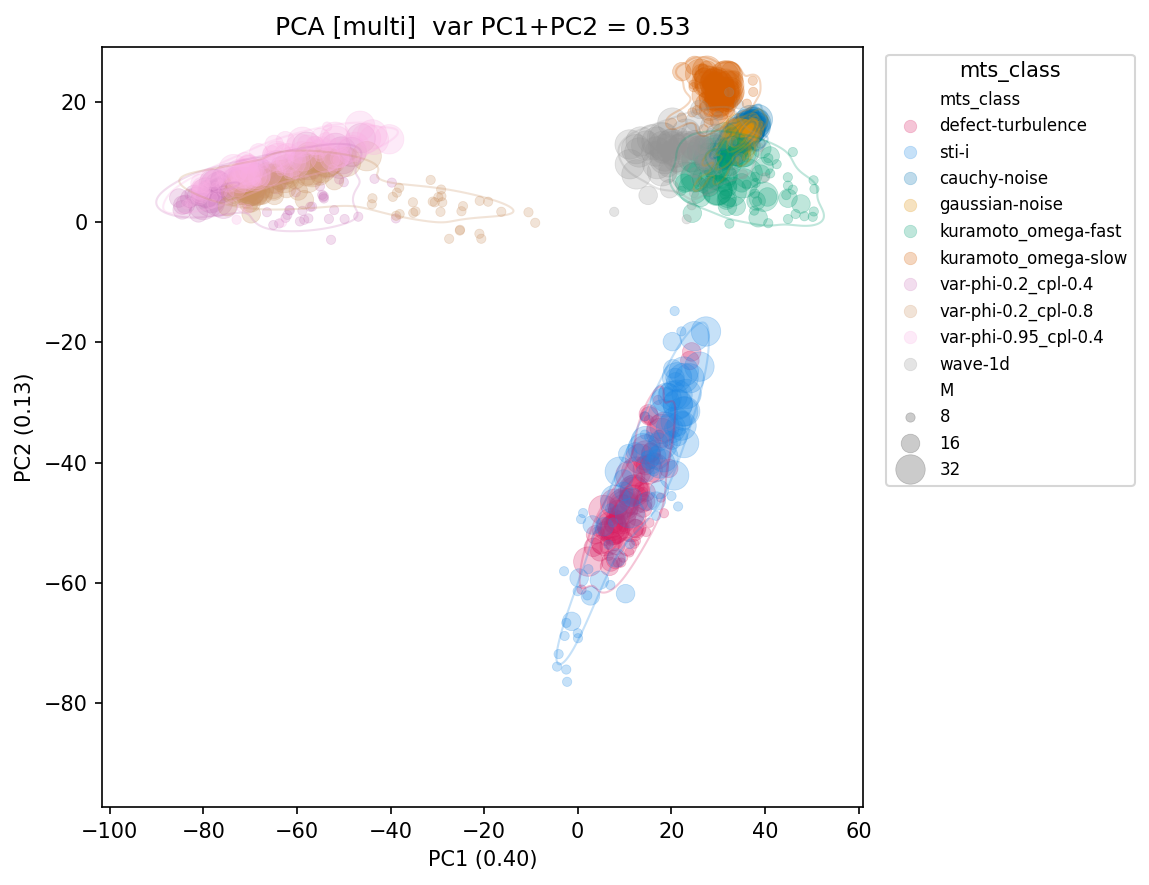

In [90]:
# PCA-2D (linear sanity check before UMAP)
plot_pca(MULTI, alpha=0.25, legend_title="mts_class"); plt.tight_layout(); plt.show()

[multi] PCA 40184 -> 50 PCs | cum var = 0.886


/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic 

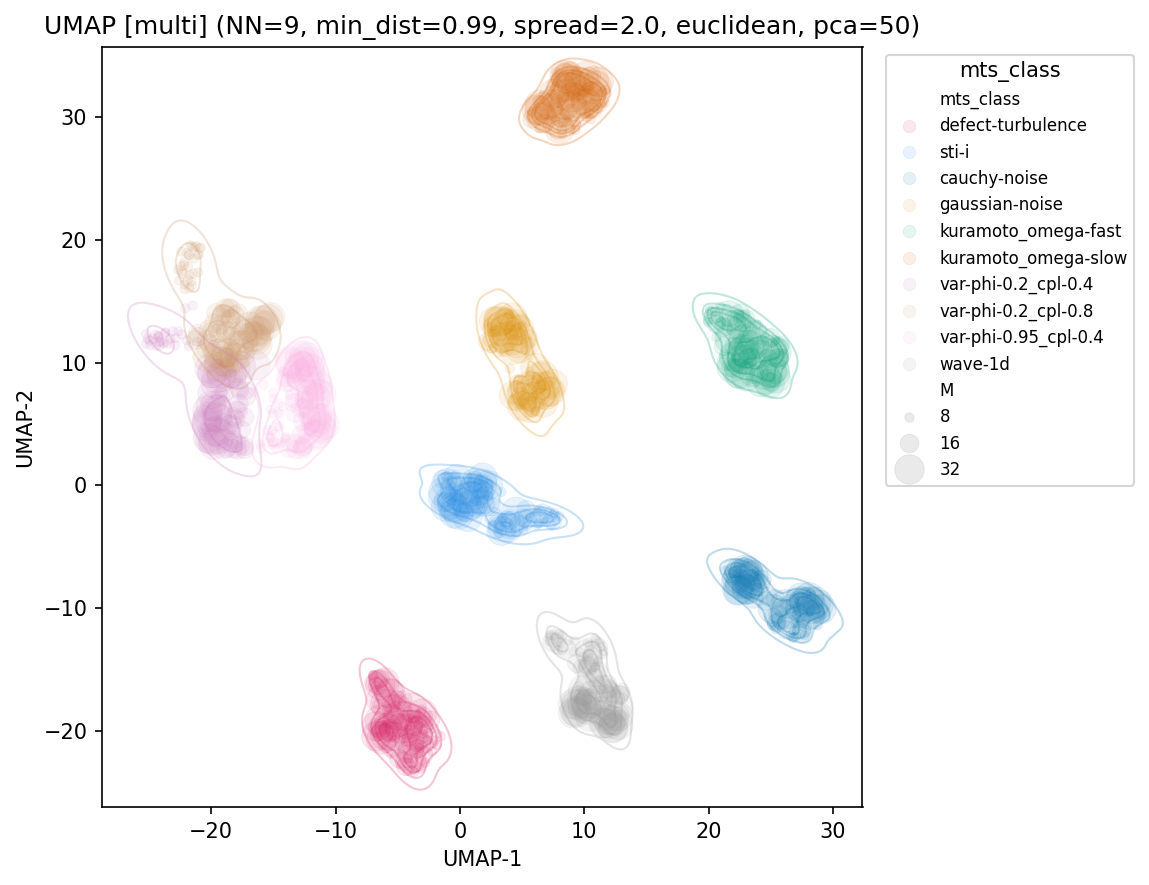

In [108]:
# --- shared embedding hyperparameters (both panels) ---
N_NEIGHBORS = 9
MIN_DIST = 0.99
SPREAD = 2.0
METRIC = "euclidean"       # after PCA, euclidean is the standard choice
SCALED = False             # covariance-PCA keeps high-variance f_ij pairs dominant
PCA_PREPROCESS = True      # p >> n: denoise/decorrelate within f_ij space before UMAP
N_PCA = 50

# UMAP-2D - Panel A
emb_multi, df_multi, _ = plot_umap(MULTI, n_neighbors=N_NEIGHBORS, min_dist=MIN_DIST, spread=SPREAD,
                                   alpha=0.1, 
                                   metric=METRIC, scaled=SCALED, pca_preprocess=PCA_PREPROCESS, legend_title="mts_class")
plt.tight_layout(); plt.show()

In [92]:
# interactive (exploration)
import plotly.express as px
dfp = df_multi.assign(M_str=df_multi["M"].astype(str), instance_str=df_multi["instance"].astype(str))
fig = px.scatter(dfp, x="umap_x", y="umap_y", color="mts_class", symbol="M_str",
                 hover_data={"M": True, "T": True, "instance_str": True, "M_str": False,
                             "umap_x": ":.2f", "umap_y": ":.2f"},
                 title="Panel A - multi-class UMAP (interactive)", width=900, height=700)
fig.update_traces(marker=dict(size=9, opacity=0.75)); fig.show()

## 4 - Panel B - intra-CML regime discrimination (fine)

Reduced CML subset for figure legibility. Both bridge classes (`defect-turbulence`, `sti-i`) are
kept so the panel links back to Panel A. Point size encodes M - the same regime at different (M,T)
should co-locate.

In [93]:
# CML regime subsets (edit SUBSET). Both bridge classes kept in every option below.
SUBSETS = {
    "cleanest-4":  ["fdstc", "frozen-chaos", "defect-turbulence", "sti-i"],
    "turbulence-axis-5": ["frozen-chaos", "sti-i", "defect-turbulence", "fdstc", "chaotic-traveling-wave"],
    "core-6":      None,   # all 6 regimes
}
SUBSET = "cleanest-4"

CMLsub = CML.subset(classes=SUBSETS[SUBSET])
print(f"SUBSET={SUBSET}  X={CMLsub.X.shape}  classes={sorted(set(CMLsub.y))}")

SUBSET=cleanest-4  X=(360, 40174)  classes=[np.str_('defect-turbulence'), np.str_('fdstc'), np.str_('frozen-chaos'), np.str_('sti-i')]


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

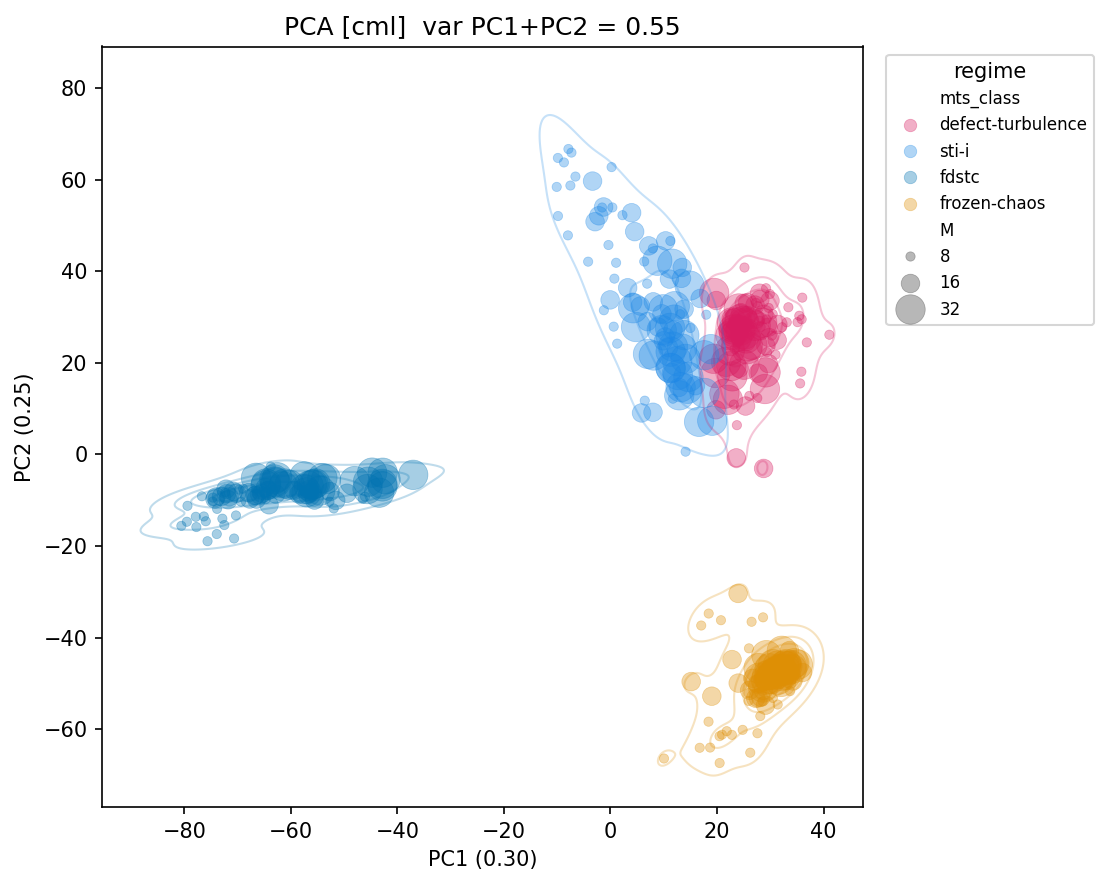

In [94]:
# PCA-2D - Panel B
plot_pca(CMLsub, legend_title="regime"); plt.tight_layout(); plt.show()

/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[cml] PCA 40174 -> 50 PCs | cum var = 0.933


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

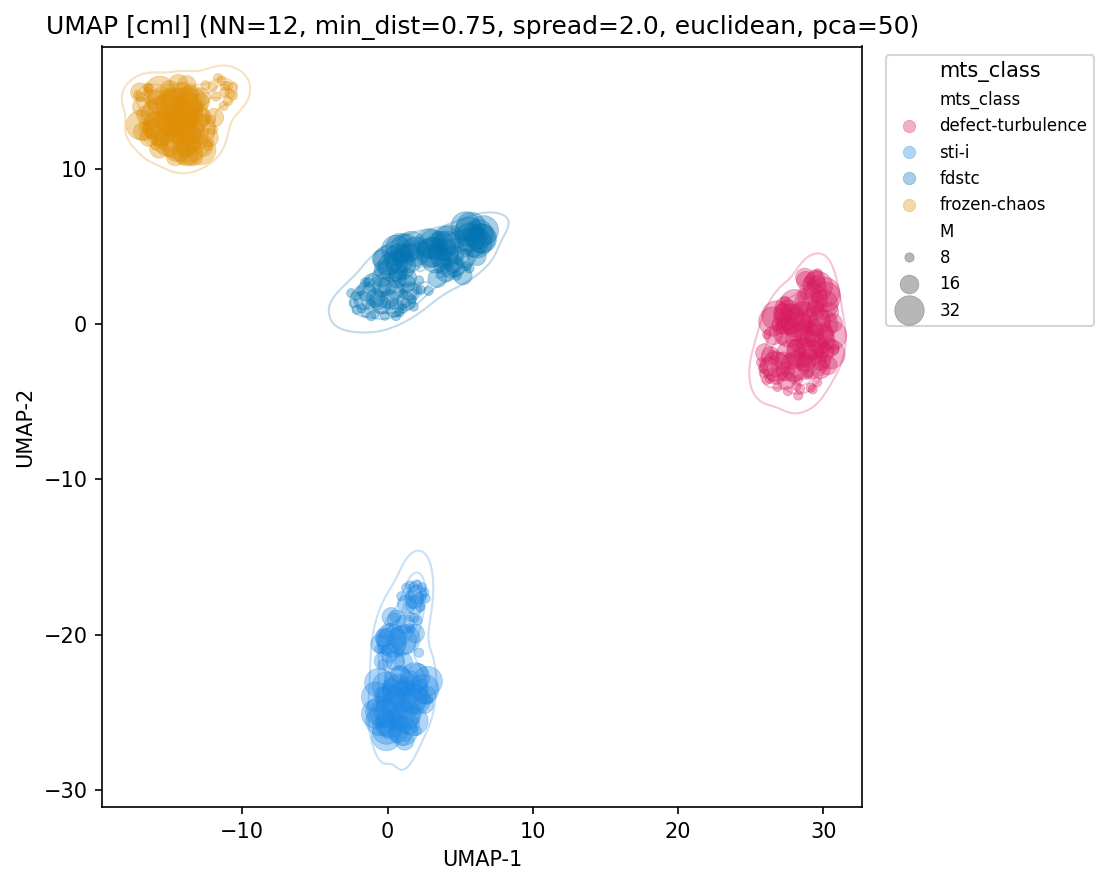

In [95]:
# --- shared embedding hyperparameters (both panels) ---
N_NEIGHBORS = 12
MIN_DIST = 0.75
SPREAD = 2.0
METRIC = "euclidean"       # after PCA, euclidean is the standard choice
SCALED = False             # covariance-PCA keeps high-variance f_ij pairs dominant
PCA_PREPROCESS = True      # p >> n: denoise/decorrelate within f_ij space before UMAP
N_PCA = 50

# UMAP-2D - Panel B
emb_multi, df_multi, _ = plot_umap(CMLsub, n_neighbors=N_NEIGHBORS, min_dist=MIN_DIST, spread=SPREAD, 
                                   metric=METRIC, scaled=SCALED, pca_preprocess=PCA_PREPROCESS, legend_title="mts_class")
plt.tight_layout(); plt.show()

In [96]:
# interactive (exploration)
dfp = df_cml.assign(M_str=df_cml["M"].astype(str), instance_str=df_cml["instance"].astype(str))
fig = px.scatter(dfp, x="umap_x", y="umap_y", color="mts_class", symbol="M_str",
                 hover_data={"M": True, "T": True, "instance_str": True, "M_str": False,
                             "umap_x": ":.2f", "umap_y": ":.2f"},
                 title=f"Panel B - CML {SUBSET} UMAP (interactive)", width=900, height=700)
fig.update_traces(marker=dict(size=9, opacity=0.75)); fig.show()

## 5 - Combined two-panel figure

The publication figure: coarse separation (A) beside fine intra-family separation (B). Reuses the
UMAP embeddings from the panel cells above (`df_multi`, `df_cml`); bridge classes carry identical
colours across both via the shared lock.

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

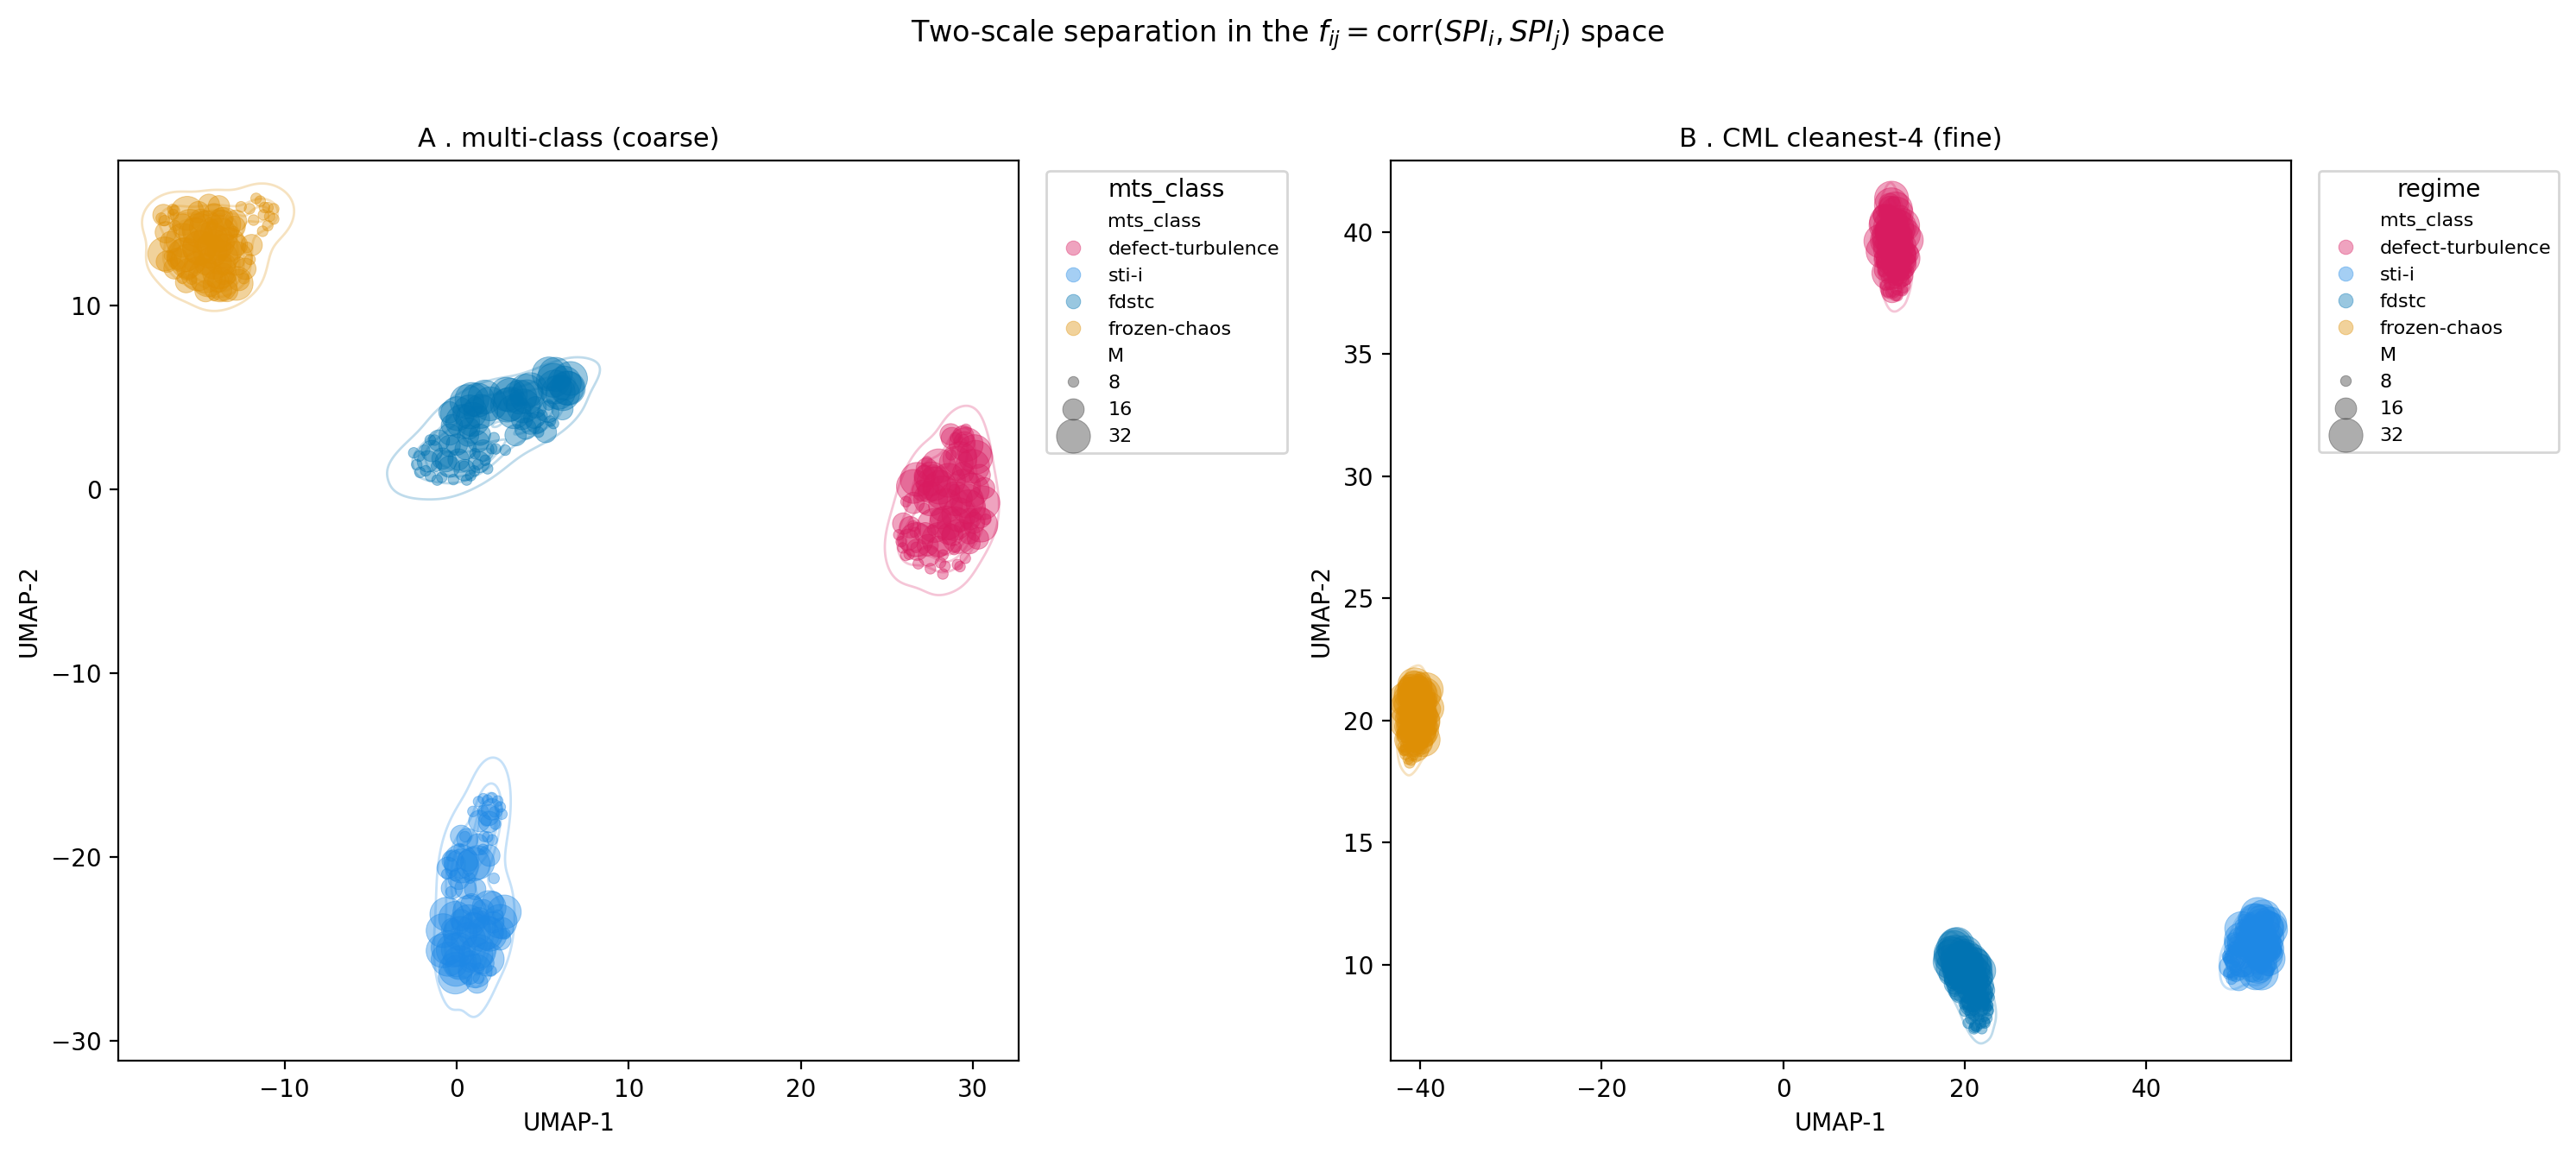

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), dpi=200)
_scatter(df_multi, "umap_x", "umap_y", ax=axes[0], alpha=0.4, legend_title="mts_class")
axes[0].set_title("A . multi-class (coarse)", fontsize=11)
_scatter(df_cml, "umap_x", "umap_y", ax=axes[1], alpha=0.4, legend_title="regime")
axes[1].set_title(f"B . CML {SUBSET} (fine)", fontsize=11)
for ax in axes:
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
fig.suptitle(r"Two-scale separation in the $f_{ij} = \mathrm{corr}(SPI_i, SPI_j)$ space", y=1.02)
fig.tight_layout()
# fig.savefig("graphics/proof_p90_two_panel.svg", bbox_inches="tight")
plt.show()

## 6 - Discriminative `f_ij` features (per class pair)

Rank single SPI-SPI features by how well they separate a chosen class pair, then plot the top ones
as rainclouds to show the learnable boundary. Scoring = **AUC / Mann-Whitney** (`sep = max(AUC,
1-AUC)`, 0.5=chance, 1=perfect), with **KS** as a shape-difference flag and a **permutation null on
the best-of-all-features** to control selection bias over ~40k pairs. `by_cell=True` reports the
**min over (M,T) cells** (dimension-invariant separation); the gap (pooled - min_cell) flags
M-confounding. Points coloured by class, sized by M.

All functions take a `FeatureSet`, so the same tools work on `CML` (fine, same-family pairs) or
`MULTI` (coarse pairs) - set `SRC` below.

In [98]:
from matplotlib.colors import to_rgba

def plot_rainclouds(ax, category_labels, data_array, *, order=None, colors=None,
                    size_by=None, size_range=(18, 95), size_label="M", add_size_legend=True,
                    half_width=0.28, box_width=0.045, point_size=5, point_alpha=0.20,
                    jitter=0.02, rng=0):
    """Raincloud per category: cloud = right-half violin joined at its base to a narrow box;
    raw points jittered to the left (long-form input a la Makie rainclouds()). Returns ax.
    Points take their category colour (faint fill, strong outline); size_by scales markers."""
    data_array = np.asarray(data_array, float)
    category_labels = np.asarray(category_labels)
    cats = list(order) if order is not None else list(dict.fromkeys(category_labels.tolist()))
    if colors is None:
        colors = list(sns.color_palette("tab10", len(cats)))
    rs = np.random.default_rng(rng)
    smin = smax = None
    if size_by is not None:
        size_by = np.asarray(size_by, float)
        smin, smax = np.nanmin(size_by), np.nanmax(size_by)
    _to_size = lambda v: size_range[0] + (v - smin) / (smax - smin + 1e-9) * (size_range[1] - size_range[0])

    for i, cat in enumerate(cats):
        m = category_labels == cat
        fin = np.isfinite(data_array[m])
        vals = data_array[m][fin]
        pos, col = i, colors[i % len(colors)]
        if len(vals) >= 2 and np.std(vals) > 1e-9:                       # right-half violin
            for b in ax.violinplot([vals], positions=[pos], widths=half_width * 2,
                                   showextrema=False)["bodies"]:
                v = b.get_paths()[0].vertices
                v[:, 0] = np.clip(v[:, 0], pos, np.inf)
                b.set_facecolor(col); b.set_alpha(0.35); b.set_edgecolor("none")
        if len(vals):                                                    # joined narrow box
            ax.boxplot([vals], positions=[pos], widths=box_width, showfliers=False,
                       patch_artist=True, boxprops=dict(facecolor="white", edgecolor=col, lw=1),
                       medianprops=dict(color=col, lw=1.4), whiskerprops=dict(color=col),
                       capprops=dict(color=col))
            jit = pos - box_width - 0.01 - np.abs(rs.normal(0, jitter, len(vals)))  # strip left
            s = _to_size(size_by[m][fin]) if size_by is not None else point_size
            ax.scatter(jit, vals, s=s, facecolors=to_rgba(col, point_alpha),
                       edgecolors=col, linewidths=0.7, zorder=3)
    ax.set_xticks(range(len(cats))); ax.set_xticklabels(cats)
    ax.set_xlim(-0.6, len(cats) - 0.4); ax.grid(True, axis="y", alpha=0.3)
    if size_by is not None and add_size_legend:
        uvals = np.unique(size_by[np.isfinite(size_by)])
        handles = [ax.scatter([], [], s=_to_size(u), facecolors=to_rgba("0.4", point_alpha),
                              edgecolors="0.4", linewidths=0.7, label=f"{int(u)}") for u in uvals]
        ax.legend(handles=handles, title=size_label, labelspacing=1.1, frameon=True,
                  loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
    return ax

In [99]:
from scipy.stats import rankdata, ks_2samp

def _auc(R, mask_a, na, nb):
    """Directional AUC = P(A>B) per feature from combined-sample ranks R (n x p)."""
    return (R[mask_a].sum(0) - na * (na + 1) / 2) / (na * nb)

def _ks(X, mask_a, na, nb):
    """Vectorised two-sample KS per column: max |ECDF_a - ECDF_b|."""
    order = np.argsort(X, axis=0)
    step = np.where(mask_a[order], 1.0 / na, -1.0 / nb)
    return np.max(np.abs(np.cumsum(step, axis=0)), axis=0)

def pair_separation(fs, a, b, by_cell=True, n_perm=200, rng=0):
    """Rank every f_ij by class-pair separability on a FeatureSet. Returns (df sorted, null_max).
    df cols: spi_i, spi_j, sep(=max AUC), auc, ks, margin, [min_cell_sep], idx."""
    Xall, yall, Mall, Tall, PAIRS = fs.X, fs.y, fs.M, fs.T, fs.pairs
    m = np.isin(yall, [a, b])
    Xab, yab, Mab, Tab = Xall[m], yall[m], Mall[m], Tall[m]
    mask_a = yab == a; na = int(mask_a.sum()); nb = int(len(mask_a) - na)
    R = rankdata(Xab, axis=0)
    auc = _auc(R, mask_a, na, nb); sep = np.maximum(auc, 1 - auc)
    ks = _ks(Xab, mask_a, na, nb)
    med_a = np.median(Xab[mask_a], axis=0); med_b = np.median(Xab[~mask_a], axis=0)
    mad = np.median(np.abs(Xab - np.median(Xab, axis=0)), axis=0) * 1.4826 + 1e-9
    margin = (med_a - med_b) / mad                                  # robust standardised median gap
    cols = {"idx": np.arange(len(sep)), "sep": sep, "auc": auc, "ks": ks, "margin": margin}
    if by_cell:
        mc = np.ones_like(sep)
        for mm in np.unique(Mab):
            for tt in np.unique(Tab):
                cm = (Mab == mm) & (Tab == tt); ca = mask_a[cm]
                nca = int(ca.sum()); ncb = int(cm.sum() - nca)
                if nca and ncb:
                    ac = _auc(rankdata(Xab[cm], axis=0), ca, nca, ncb)
                    mc = np.minimum(mc, np.maximum(ac, 1 - ac))
        cols["min_cell_sep"] = mc
    rs = np.random.default_rng(rng); base = na * (na + 1) / 2; null_max = np.empty(n_perm)
    for i in range(n_perm):                                         # null on best-of-all sep
        ac = (rs.permutation(mask_a) @ R - base) / (na * nb)
        null_max[i] = np.maximum(ac, 1 - ac).max()
    df = pd.DataFrame(cols)
    df["spi_i"] = PAIRS[df["idx"].to_numpy(), 0]; df["spi_j"] = PAIRS[df["idx"].to_numpy(), 1]
    df["absmargin"] = df["margin"].abs()
    sort_key = "min_cell_sep" if by_cell else "sep"
    df = df.sort_values([sort_key, "absmargin"], ascending=False).reset_index(drop=True)
    keep = ["spi_i", "spi_j", "sep", "auc", "ks", "margin"] + (["min_cell_sep"] if by_cell else []) + ["idx"]
    return df[keep], null_max

def youden_threshold(va, vb):
    """Single-feature decision threshold maximising sensitivity + specificity (Youden J)."""
    vals = np.r_[va, vb]; best_t, best_j = float(vals.mean()), -1.0
    for t in np.unique(vals):
        j = (va > t).mean() + (vb <= t).mean() - 1
        if j > best_j:
            best_j, best_t = j, t
    return best_t

def train_test_separation(fs, a, b, test_frac=0.4, rng=0):
    """Held-out check: rank by sep on a train split, report sep on held-out test. The
    train->test drop is the selection-bias optimism. Stratified per class."""
    Xall, yall, PAIRS = fs.X, fs.y, fs.pairs
    m = np.isin(yall, [a, b]); yv = yall[m]
    rs = np.random.default_rng(rng); is_test = np.zeros(len(yv), bool)
    for c in (a, b):
        ci = np.where(yv == c)[0]; rs.shuffle(ci)
        is_test[ci[:int(round(test_frac * len(ci)))]] = True
    def _sep(sel):
        Xs = Xall[m][sel]; ms = (yv == a)[sel]; na = int(ms.sum()); nb = int(len(ms) - na)
        au = _auc(rankdata(Xs, axis=0), ms, na, nb); return np.maximum(au, 1 - au)
    df = pd.DataFrame({"idx": np.arange(Xall.shape[1]),
                       "train_sep": _sep(~is_test), "test_sep": _sep(is_test)})
    df["spi_i"] = PAIRS[df["idx"].to_numpy(), 0]; df["spi_j"] = PAIRS[df["idx"].to_numpy(), 1]
    df = df.sort_values("train_sep", ascending=False).reset_index(drop=True)
    return df[["spi_i", "spi_j", "train_sep", "test_sep", "idx"]]

def plot_feature_hist(fs, class_a, class_b, spi_i, spi_j, *, bins=9, ax=None,
                      colors=("#4C72B0", "#DD8452")):
    """Overlaid density histograms of corr(spi_i, spi_j) for two classes. Returns ax."""
    i = fs.feature_column(spi_i, spi_j)
    if ax is None:
        _, ax = plt.subplots(figsize=(6.5, 4.2))
    for c, col in zip((class_a, class_b), colors):
        v = fs.X[fs.y == c, i]; v = v[np.isfinite(v)]
        ax.hist(v, bins=bins, density=True, alpha=0.6, color=col, edgecolor=col, label=c)
    ax.set_xlabel(f"corr({spi_i}, {spi_j})"); ax.set_ylabel("density"); ax.legend()
    ax.set_box_aspect(1)
    return ax

### 6.1 - Pick a class pair, rank features

`SRC` selects the matrix. Default `CML` for the fine same-family story; switch to `MULTI` for any
coarse pair (e.g. a null vs a structured generator).

In [100]:
SRC = CML          # CML (fine) | MULTI (coarse)
CLASS_A = "sti-i"
CLASS_B = "defect-turbulence"
TOPK = 24

ranked, null_max = pair_separation(SRC, CLASS_A, CLASS_B, by_cell=True, n_perm=200)
null95 = np.quantile(null_max, 0.95)
print(f"[{SRC.name}] {CLASS_A} vs {CLASS_B}: best-of-all permutation null (95th pct) sep = {null95:.3f}")
print(f"features clearing null: sep>null95 = {(ranked['sep']>null95).sum()}, "
      f"perfect pooled sep=1.0: {(ranked['sep']>=0.999).sum()}, "
      f"dim-invariant min_cell=1.0: {(ranked['min_cell_sep']>=0.999).sum()}")
ranked.head(TOPK)

[cml] sti-i vs defect-turbulence: best-of-all permutation null (95th pct) sep = 0.684
features clearing null: sep>null95 = 23987, perfect pooled sep=1.0: 2693, dim-invariant min_cell=1.0: 2742


,spi_i,spi_j,sep,auc,ks,margin,min_cell_sep,idx
0,corr_spearman_tau-20,corr_kendall_tau-20,0.995309,0.004691,0.955556,-12.628750,1.0,15656
1,corr_pearson_tau-5,pec_orth_log,0.999136,0.999136,0.988889,9.360444,1.0,10767
2,ce_gaussian,xme_gaussian_k1,1.000000,0.000000,1.000000,-8.996757,1.0,26648
3,corr_spearman_tau-2,corr_kendall_tau-2,0.991420,0.008580,0.944444,-8.339613,1.0,13159
4,corr_pearson_tau-1,pec_orth_log,0.999136,0.999136,0.988889,8.101603,1.0,9789
5,pdist_cityblock,pec_orth_log,0.999136,0.999136,0.988889,8.091046,1.0,20667
6,pdist_canberra,pec_orth_log,0.999012,0.999012,0.988889,7.424157,1.0,21255
7,pdist_braycurtis,pec_orth_log,0.999136,0.999136,0.988889,7.419014,1.0,21449
8,pdist_cosine,pec_orth_log,0.999136,0.999136,0.988889,7.137947,1.0,20864
9,corr_pearson_tau-4,corr_kendall_tau-4,1.000000,0.000000,1.000000,-7.125787,1.0,10311


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found becau

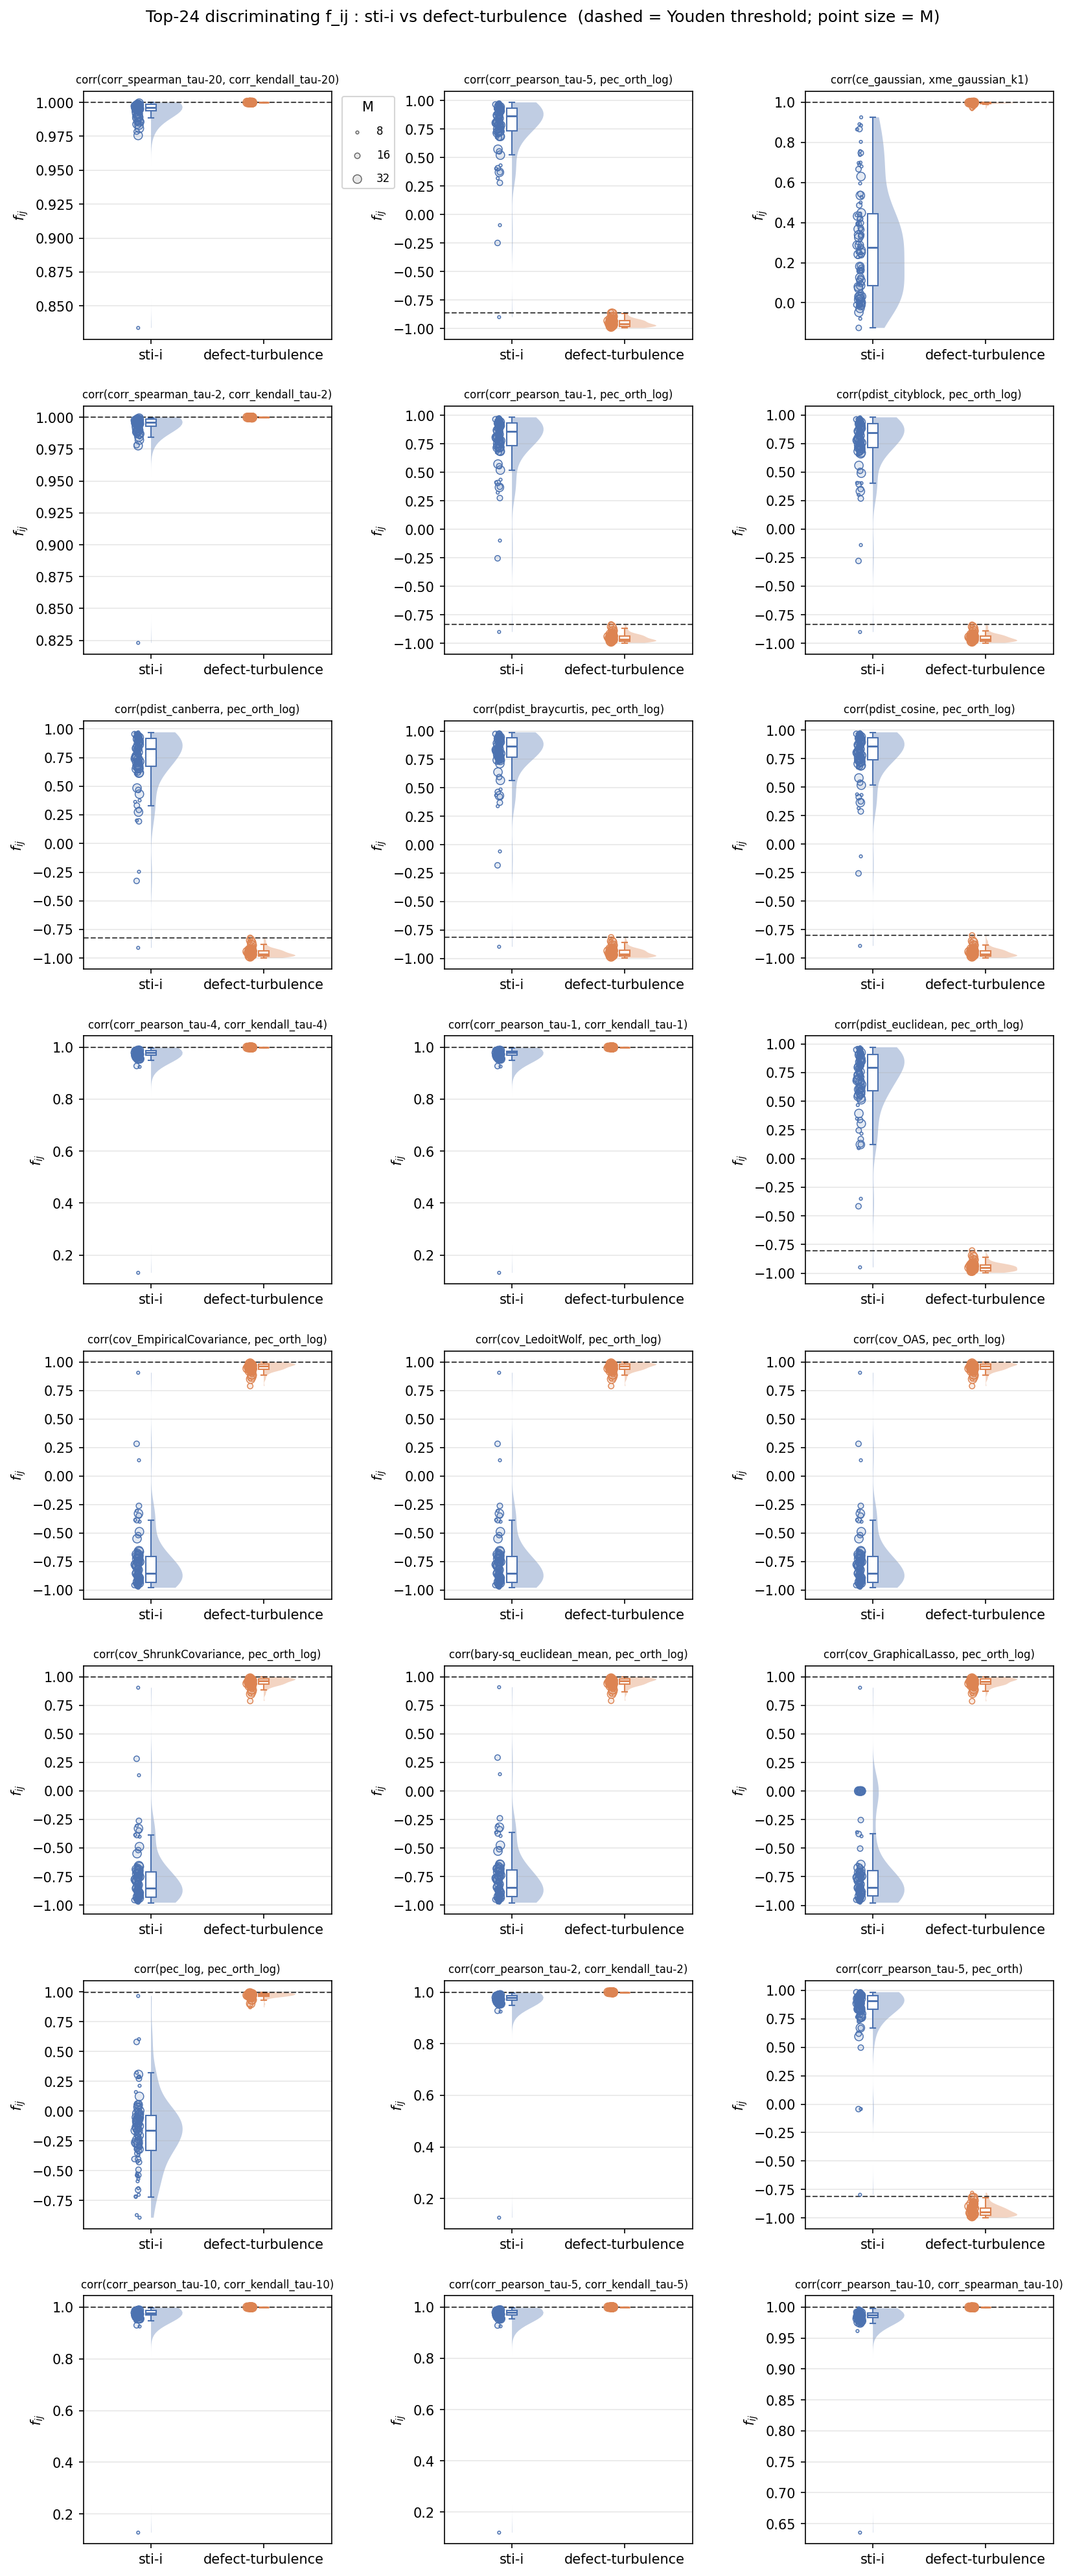

In [101]:
# Top-K *diverse* discriminating features as rainclouds (skip a pair only if BOTH SPIs already shown)
ncol = 3; nrow = int(np.ceil(TOPK / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.6*ncol, 3.3*nrow), dpi=150)
axes = np.atleast_1d(axes).ravel()
m = np.isin(SRC.y, [CLASS_A, CLASS_B])
Xab, yab, Mab = SRC.X[m], SRC.y[m], SRC.M[m]
used = set(); picks = []
for _, r in ranked.iterrows():
    s0, s1 = r["spi_i"], r["spi_j"]
    if s0 in used and s1 in used:
        continue
    picks.append(r); used.update([s0, s1])
    if len(picks) >= TOPK:
        break
for k, row in enumerate(picks):
    i = int(row["idx"]); ax = axes[k]
    va, vb = Xab[yab==CLASS_A, i], Xab[yab==CLASS_B, i]
    plot_rainclouds(ax, yab, Xab[:, i], order=[CLASS_A, CLASS_B],
                    colors=["#4C72B0", "#DD8452"], size_by=Mab, size_range=(5, 40),
                    point_size=10, point_alpha=0.15, box_width=0.09, add_size_legend=(k == 0))
    ax.axhline(youden_threshold(va, vb), color="k", ls="--", lw=1, alpha=0.7)
    ax.set_title(f"corr({row['spi_i']}, {row['spi_j']})", fontsize=8)
    ax.set_ylabel(r"$f_{ij}$"); ax.set_box_aspect(1)
for k in range(len(picks), len(axes)): axes[k].axis("off")
fig.suptitle(f"Top-{TOPK} discriminating f_ij : {CLASS_A} vs {CLASS_B}  "
             f"(dashed = Youden threshold; point size = M)", y=1.005)
fig.tight_layout(); plt.show()

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

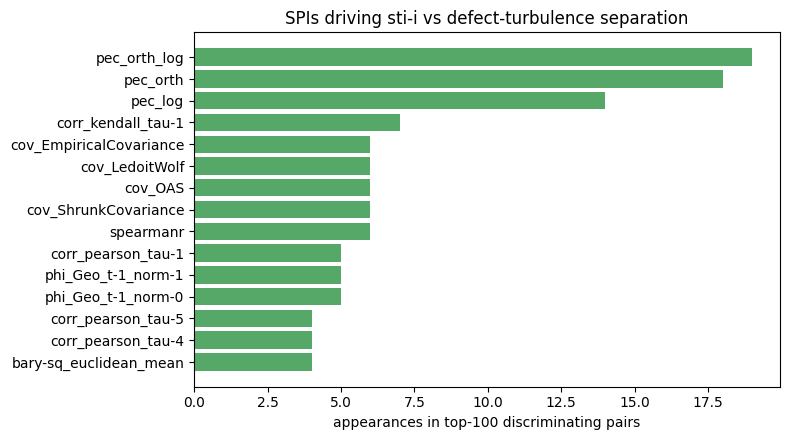

In [102]:
# Which individual SPIs recur across the top discriminating pairs? Names the dependence axes.
from collections import Counter
TOP_FOR_UNION = 100
cnt = Counter()
for _, r in ranked.head(TOP_FOR_UNION).iterrows():
    cnt[r["spi_i"]] += 1; cnt[r["spi_j"]] += 1
top_spi = cnt.most_common(15)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh([s for s, _ in top_spi][::-1], [c for _, c in top_spi][::-1], color="#55A868")
ax.set_xlabel(f"appearances in top-{TOP_FOR_UNION} discriminating pairs")
ax.set_title(f"SPIs driving {CLASS_A} vs {CLASS_B} separation"); fig.tight_layout(); plt.show()

### 6.2 - Single raincloud - two classes x two SPIs

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

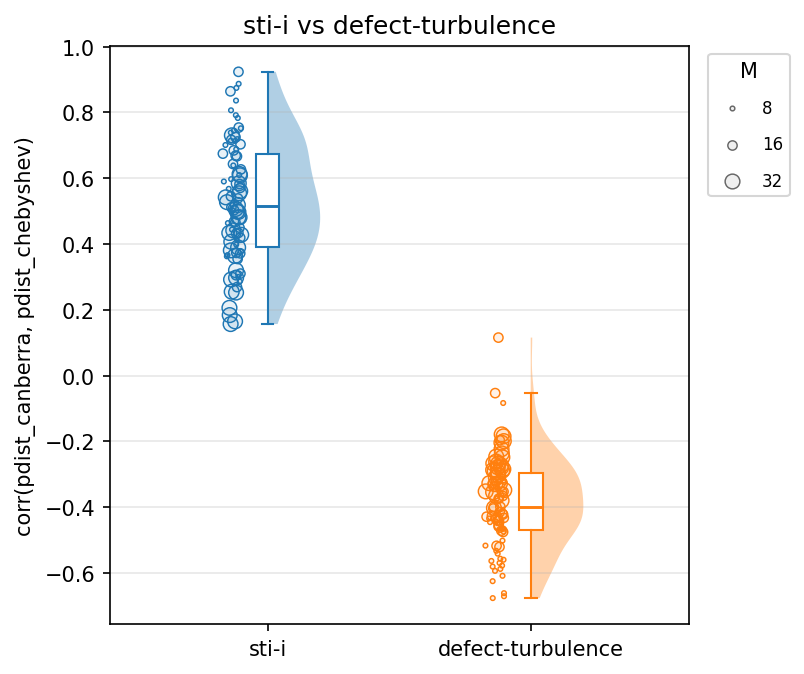

In [103]:
CLASS_A = "sti-i"
CLASS_B = "defect-turbulence"
spi_i = "pdist_canberra"
spi_j = "pdist_chebyshev"

i = SRC.feature_column(spi_i, spi_j)
m = np.isin(SRC.y, [CLASS_A, CLASS_B])
fig, ax = plt.subplots(figsize=(6.5, 4.6), dpi=150)
plot_rainclouds(ax, SRC.y[m], SRC.X[m, i], order=[CLASS_A, CLASS_B],
                half_width=0.20, box_width=0.09, jitter=0.03,
                size_by=SRC.M[m], size_range=(5, 50), point_size=10, point_alpha=0.10)
ax.set_ylabel(f"corr({spi_i}, {spi_j})"); ax.set_title(f"{CLASS_A} vs {CLASS_B}")
ax.set_box_aspect(1); plt.tight_layout(); plt.show()

### 6.3 - Histogram alternative (density)

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern
findfont: 

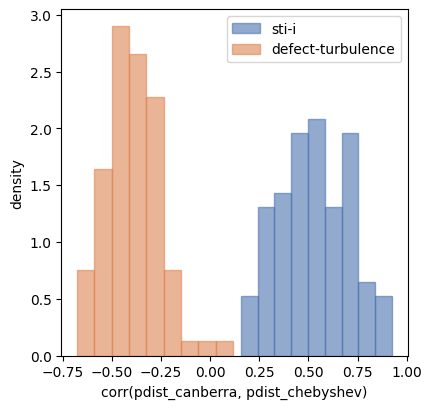

In [104]:
plot_feature_hist(SRC, CLASS_A, CLASS_B, spi_i, spi_j); plt.tight_layout(); plt.show()

### 6.4 - KS-stat ranking (shape-difference flag)

In [105]:
ranked.sort_values("ks", ascending=False).head(TOPK)

,spi_i,spi_j,sep,auc,ks,margin,min_cell_sep,idx
2555,spearmanr,corr_spearman_tau-5-sq,1.0,1.0,1.0,1.297173,1.0,8824
1743,cov-sq_ShrunkCovariance,spearmanr,1.0,1.0,1.0,1.406516,1.0,4145
1746,corr_spearman_tau-2,corr_spearman_tau-5,1.0,1.0,1.0,1.405948,1.0,13148
1747,cov_EllipticEnvelope,cov-sq_EmpiricalCovariance,1.0,1.0,1.0,1.405585,1.0,286
1748,cov_EllipticEnvelope,cov-sq_LedoitWolf,1.0,1.0,1.0,1.405585,1.0,290
1749,cov_EllipticEnvelope,cov-sq_OAS,1.0,1.0,1.0,1.405585,1.0,292
1750,cov_EllipticEnvelope,cov-sq_ShrunkCovariance,1.0,1.0,1.0,1.405585,1.0,293
1751,corr_spearman_tau-10,bary-sq_dtw_mean,1.0,0.0,1.0,-1.405265,1.0,15245
1752,corr_kendall_tau-4-sq,pdist_cosine,1.0,0.0,1.0,-1.405200,1.0,17821
1753,prec_OAS,corr_spearman_tau-3,1.0,0.0,1.0,-1.405056,1.0,6012


### 6.5 - Held-out train/test separation

Rank by sep on 60% train, report sep on 40% held-out test. A large train->test drop = selection-bias
optimism; stable `test_sep` = a real boundary.

In [106]:
ht = train_test_separation(SRC, CLASS_A, CLASS_B, test_frac=0.4)
print(f"[{SRC.name}] {CLASS_A} vs {CLASS_B}: top features by TRAIN sep, with held-out TEST sep")
ht.head(20)

[cml] sti-i vs defect-turbulence: top features by TRAIN sep, with held-out TEST sep


,spi_i,spi_j,train_sep,test_sep,idx
0,corr_spearman_tau-4-sq,pec,1.0,1.000000,14967
1,cov-sq_EmpiricalCovariance,corr_spearman_tau-1,1.0,1.000000,2268
2,cov-sq_EmpiricalCovariance,corr_spearman_tau-3,1.0,1.000000,2270
3,cov-sq_EmpiricalCovariance,corr_spearman_tau-4,1.0,0.999228,2271
4,cov-sq_EmpiricalCovariance,corr_spearman_tau-5,1.0,1.000000,2272
5,corr_kendall_tau-10-sq,gc_gaussian_k-1_kt-1_l-1_lt-1,1.0,1.000000,18509
6,corr_kendall_tau-10-sq,phi_Geo_t-1_norm-0,1.0,1.000000,18515
7,corr_kendall_tau-10-sq,phi_Geo_t-1_norm-1,1.0,1.000000,18516
8,corr_pearson_tau-10-sq,phi_Geo_t-1_norm-0,1.0,1.000000,12313
9,cov-sq_EmpiricalCovariance,corr_spearman_tau-10,1.0,1.000000,2278
